In [21]:
import cv2
import numpy as np
from skimage.morphology import skeletonize, dilation, square
from skimage import data
from matplotlib import pyplot as plt

In [23]:
def color_segmentation(img, lower_color, upper_color):
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_img, lower_color, upper_color)
    ribbon_segment = cv2.bitwise_and(img, img, mask=mask)
    return mask, ribbon_segment

def start(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    mask_red = mask_red1 + mask_red2

    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    # Convert mask_red to a format compatible with cvtColor
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.show()

    gray_img = cv2.cvtColor(result_image, cv2.COLOR_RGB2GRAY)
    plt.imshow(gray_img, cmap='gray')
    plt.show()
    
    _, black_white = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)
    
    plt.title("Binary Image")
    plt.imshow(black_white, cmap='gray')
    plt.show()

    # Normalize the image to range [0, 1] for skeletonization
    black_white_norm = black_white // 255

    skel_img = skeletonize(black_white_norm).astype(np.uint8)

    dilated_skeleton = dilation(skel_img, square(3))

    plt.title("Skeletonized Image")
    plt.imshow(dilated_skeleton, cmap='gray')
    plt.axis('off')
    plt.show()


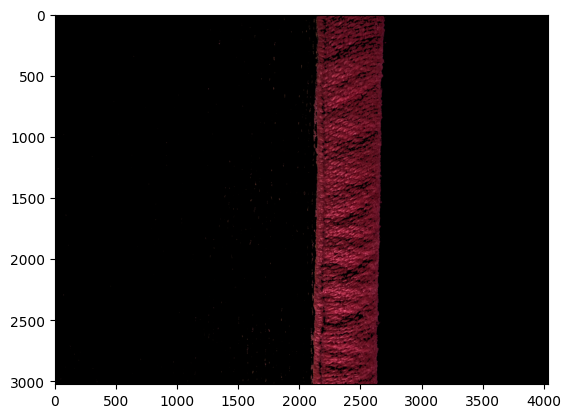

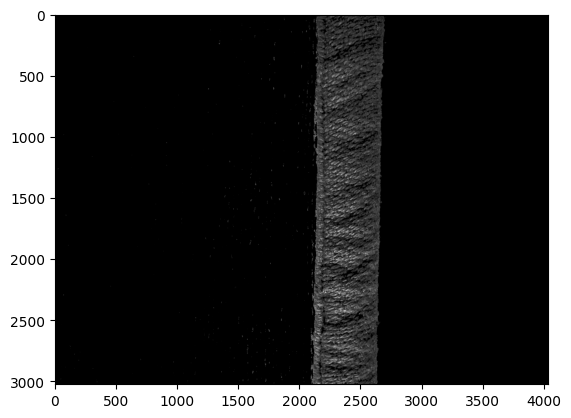

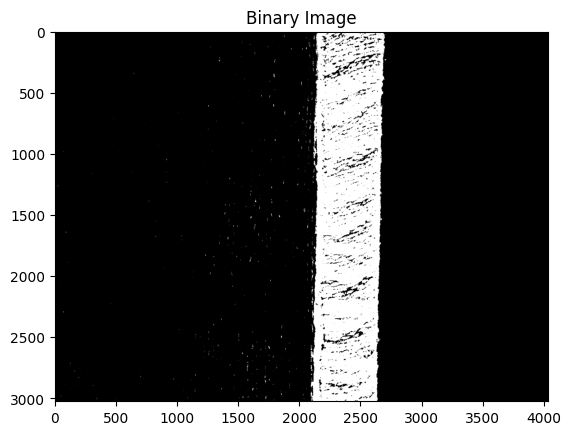

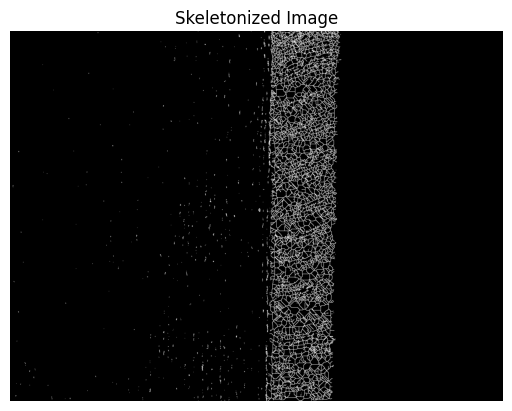

In [25]:
if __name__ == '__main__':
    # cap = cv2.VideoCapture(0)
    # while True:
    #     ret, img = cap.read()
    #     if not ret:
    #         print("Capture failed")
    #         break
    #     start(img)

    img = cv2.imread('/Users/sagar/Documents/GitHub/BDSpot/IMG_8422.JPG')
    if img is not None:
        start(img)
    else:
        print("Error: Image not found")

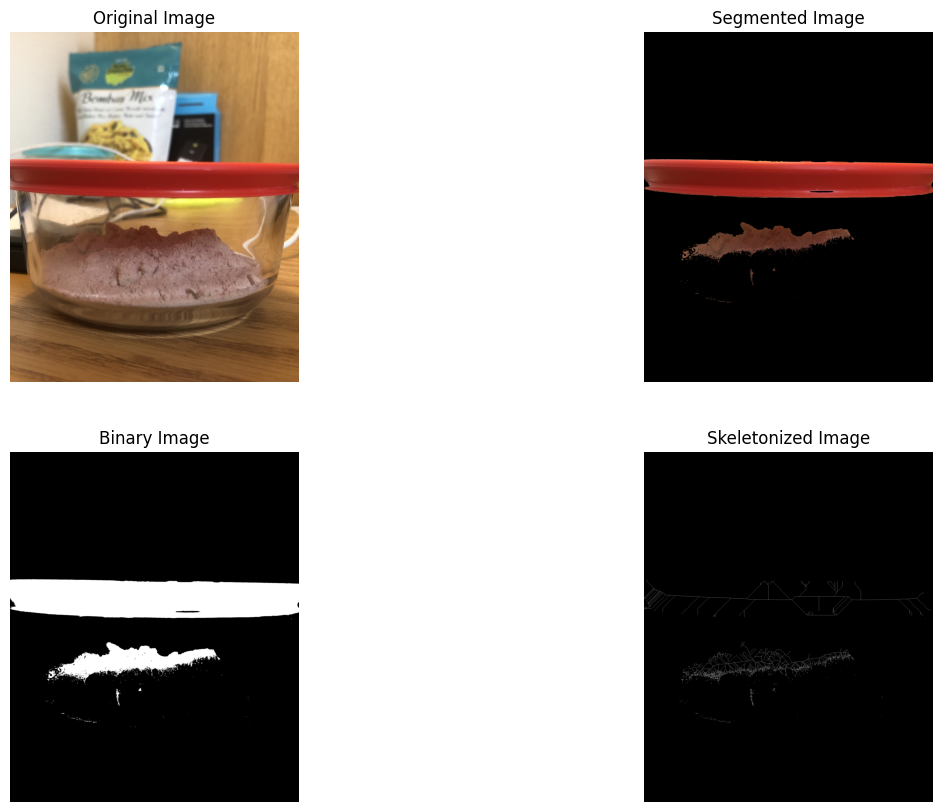

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage import img_as_ubyte

def identify_red_ribbon(img):
    # Convert BGR to HSV
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Define the red color range
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    # Combine both masks
    mask_red = mask_red1 + mask_red2

    # Apply mask to original image
    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    # Convert to RGB for Matplotlib
    result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

    # Convert the result image to grayscale
    gray_img = cv2.cvtColor(result_image, cv2.COLOR_BGR2GRAY)

    # Apply binary threshold
    _, binary_img = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)

    # Perform skeletonization
    binary_img_bool = binary_img.astype(np.bool_)
    skeleton = skeletonize(binary_img_bool)
    skeleton_img = img_as_ubyte(skeleton)

    # Plot the images
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(result_image_rgb)
    plt.title("Segmented Image")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(binary_img, cmap='gray')
    plt.title("Binary Image")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(skeleton_img, cmap='gray')
    plt.title("Skeletonized Image")
    plt.axis('off')

    plt.show()

# Test the function with an example image
if __name__ == '__main__':
    # Load an example image (you can replace this with your own image path)
    img = cv2.imread('/Users/sagar/Documents/GitHub/BDSpot/IMG_8420.jpg')
    if img is not None:
        identify_red_ribbon(img)
    else:
        print("Error: Image not found")